# HER2-IHC Hybrid Ensemble - Training on Google Colab

**Paper**: *Bridging Global Attention and Local Hierarchies: A Robust Hybrid Ensemble
Framework with Multi-Scale Feature Fusion for Automated HER2 Scoring in Breast Pathology*

Pipeline:
1. Runtime & GPU check
2. Mount Google Drive & clone/pull repo
3. Install dependencies
4. Imports and helper utilities
5. Configure Drive paths, run mode, and reporting flags
6. Resolved config report
7. Resume check: use `latest.pt` if present, otherwise start fresh
8. Auto-resume check
9. Download/extract HER2-IHC-40x patch dataset if missing
10. Dataset gate (GATE 1): split/class counts, imbalance, missing folders
11. Sample-image preview grid
12. Prepare manifests and inspect dataset report
13. Smoke tests (GATE 2): model/data/checkpoint sanity
14. Train
15. Training log tail and checkpoint inventory
16. Training curves
17. Evaluate best checkpoint
18. View metrics and figures
19. Error analysis: misclassified test examples
20. Save full results JSON to Drive
21. Optional download of best checkpoint

Persistence rule: the repo runs from local Colab disk for speed. Dataset,
checkpoints, metrics, summaries, and figures are kept on Google Drive so they
survive runtime restarts.

Resume behavior is automatic: run all cells every time. If `latest.pt` exists,
training resumes from it. If no checkpoint exists, training starts fresh.

## 1. Runtime & GPU Check

Confirm a GPU is attached **before** anything else.
If you see `WARNING: No GPU` → *Runtime → Change runtime type → T4 GPU* and restart.

In [1]:
import torch
try:
    import importlib.metadata as _imd
    _torchver = _imd.version('torch')
except Exception:
    _torchver = torch.__version__

print('PyTorch version :', _torchver)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    _props = torch.cuda.get_device_properties(0)
    print('GPU name        :', _props.name)
    print('GPU memory (GB) :', round(_props.total_memory / 1e9, 1))
    print('CUDA version    :', torch.version.cuda)
else:
    print('WARNING: No GPU found. Go to Runtime -> Change runtime type -> GPU')

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU name        : Tesla T4
GPU memory (GB) : 15.6
CUDA version    : 12.8


## 2. Mount Drive & Clone/Pull Repo

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

REPO_URL = 'https://github.com/AmineAitLaamim/HER2-model-classification.git'
REPO_DIR = '/content/HER2-model-classification'

if os.path.isdir(os.path.join(REPO_DIR, '.git')):
    print('Repo already exists -> pulling latest changes')
    %cd {REPO_DIR}
    !git pull
else:
    print('First run -> cloning repo')
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}

print('Working directory:', os.getcwd())
for _d in ['src', 'scripts', 'configs']:
    print(f'  {_d}: {"OK" if os.path.isdir(_d) else "MISSING"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo already exists -> pulling latest changes
/content/HER2-model-classification
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 652 bytes | 652.00 KiB/s, done.
From https://github.com/AmineAitLaamim/HER2-model-classification
   2ec42c8..3ff3241  main       -> origin/main
Updating 2ec42c8..3ff3241
Fast-forward
 configs/default.yaml | 37 ++++++++++++++++++++++++++++++++-----
 1 file changed, 32 insertions(+), 5 deletions(-)
Working directory: /content/HER2-model-classification
  src: OK
  scripts: OK
  configs: OK


## 3. Install Dependencies

In [3]:
!pip install -q -r requirements.txt
print('Dependencies installed.')

Dependencies installed.


## 4. Imports

All third-party and standard-library imports in one place so later cells never fail
because of a missing import.

In [4]:
import sys
import json
import shutil
import zipfile
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IpyImage

# Make the repo's src/ package importable
sys.path.insert(0, REPO_DIR)

from src.config import load_config


def run_command(cmd):
    """Run a shell command with live output and fail loudly on errors."""
    print("$", " ".join(str(part) for part in cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {cmd}")
    return result


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


print("All imports successful.")

All imports successful.


## 5. Configuration & Drive Paths

User-editable controls:

| Flag | Default | Meaning |
|------|---------|---------|
| `DOWNLOAD_DATASET_IF_MISSING` | `True` | Download the Zenodo ZIP with resumable `wget -c` when `DATA_DIR` is missing |
| `RUN_SMOKE_TESTS` | `True` | Run GATE 2 sanity check before training |
| `DOWNLOAD_BEST` | `False` | Download `best.pt` at the end |

Set `DATA_DIR` to the HER2-IHC-40x dataset folder on your Drive. Resume is
automatic and always checks `latest.pt` before training.

In [5]:
# User-editable controls
DOWNLOAD_DATASET_IF_MISSING = True
RUN_SMOKE_TESTS = True  # True runs GATE 2 before training
DOWNLOAD_BEST   = False # True browser-downloads best.pt at the end
LOG_TAIL_LINES  = 60
DATASET_ZIP_URL = "https://zenodo.org/records/15179608/files/her2-ihc-40x-patch.zip?download=1"
DATASET_ZIP_NAME = "her2-ihc-40x-patch.zip"

# Drive paths
DRIVE_ROOT     = "/content/drive/MyDrive/HER2_Classification"
DATASET_PARENT_DIR = f"{DRIVE_ROOT}/datasets"
DOWNLOAD_DIR   = f"{DRIVE_ROOT}/downloads"
DATA_DIR       = f"{DATASET_PARENT_DIR}/her2-ihc-40x-patch"
EXPERIMENT_DIR = f"{DRIVE_ROOT}/experiments/exp001_hybrid_end_to_end"
SMOKE_DIR      = f"{DRIVE_ROOT}/experiments/smoke_test"
FIGURES_DIR    = f"{DRIVE_ROOT}/figures"
MANIFEST_DIR   = f"{DRIVE_ROOT}/dataset_manifests"
LOCAL_RUN_DIR  = "/content/her2_run"

# Paths derived from EXPERIMENT_DIR
BEST_CKPT      = f"{EXPERIMENT_DIR}/best.pt"
LATEST_CKPT    = f"{EXPERIMENT_DIR}/latest.pt"
EVAL_DIR       = f"{EXPERIMENT_DIR}/final_eval"
TRAINING_LOG   = f"{EXPERIMENT_DIR}/training.log"

# Config
CONFIG = "configs/hybrid.yaml"

for folder in [
    DRIVE_ROOT,
    DATASET_PARENT_DIR,
    DOWNLOAD_DIR,
    f"{DRIVE_ROOT}/experiments",
    FIGURES_DIR,
    MANIFEST_DIR,
    LOCAL_RUN_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("Dataset dir     :", DATA_DIR)
print("Experiment dir  :", EXPERIMENT_DIR)
print("Local run dir   :", LOCAL_RUN_DIR)
print("Config          :", CONFIG)
print("DOWNLOAD_DATASET_IF_MISSING:", DOWNLOAD_DATASET_IF_MISSING)
print("RUN_SMOKE_TESTS :", RUN_SMOKE_TESTS)
print("DOWNLOAD_BEST   :", DOWNLOAD_BEST)

Dataset dir     : /content/drive/MyDrive/HER2_Classification/datasets/her2-ihc-40x-patch
Experiment dir  : /content/drive/MyDrive/HER2_Classification/experiments/exp001_hybrid_end_to_end
Local run dir   : /content/her2_run
Config          : configs/hybrid.yaml
DOWNLOAD_DATASET_IF_MISSING: True
RUN_SMOKE_TESTS : True
DOWNLOAD_BEST   : False


## 6. Resolved Config Report

Loads `configs/hybrid.yaml` through the project config loader so inherited defaults
are visible before training starts.

In [6]:
resolved_config = load_config(CONFIG)

training_cfg = resolved_config["training"]
dataset_cfg = resolved_config["dataset"]
model_cfg = resolved_config["model"]
CLASSES = [name for name, _ in sorted(resolved_config["classes"].items(), key=lambda item: item[1])]

print("Seed              :", resolved_config["seed"])
print("Classes           :", CLASSES)
print("Image size        :", dataset_cfg["image_size"])
print("Batch size        :", training_cfg["batch_size"])
print("Epochs            :", training_cfg["epochs"])
print("LR / min LR       :", training_cfg["learning_rate"], "/", training_cfg["min_learning_rate"])
print("Warmup epochs     :", training_cfg["warmup_epochs"])
print("AMP               :", training_cfg["amp"], "and CUDA available =", torch.cuda.is_available())
print("Resume in config  :", training_cfg.get("resume", True))
print("Backbones:")
print("  EVA      :", model_cfg["eva_name"])
print("  ViT      :", model_cfg["vit_name"])
print("  ConvNeXt :", model_cfg["convnext_name"])

Seed              : 42
Classes           : ['class_0', 'class_1+', 'class_2+', 'class_3+']
Image size        : 224
Batch size        : 2
Epochs            : 100
LR / min LR       : 1e-05 / 1e-07
Warmup epochs     : 10
AMP               : True and CUDA available = True
Resume in config  : True
Backbones:
  EVA      : eva02_large_patch14_448.mim_m38m_ft_in22k_in1k
  ViT      : vit_base_patch16_224
  ConvNeXt : convnextv2_nano.fcmae_ft_in1k


## 7. Resume Check Setup

The notebook always keeps the experiment directory and checks for `latest.pt`.
If it exists, training resumes. If it does not exist, training starts fresh.

In [7]:
for folder in [EXPERIMENT_DIR, SMOKE_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Resume check enabled. Existing experiment outputs are kept.")
print("latest.pt path:", LATEST_CKPT)

Resume check enabled. Existing experiment outputs are kept.
latest.pt path: /content/drive/MyDrive/HER2_Classification/experiments/exp001_hybrid_end_to_end/latest.pt


## 8. Auto-Resume Check

The notebook checks for `latest.pt` on Drive:
- Found: training resumes from the last saved epoch.
- Not found: training starts from epoch 0.

This is the normal behavior for every run.

In [8]:
if os.path.exists(LATEST_CKPT):
    _ckpt = torch.load(LATEST_CKPT, map_location='cpu')
    _resumed_epoch = int(_ckpt.get('epoch', -1)) + 1
    print(f'RESUME MODE  — latest.pt found on Drive.')
    print(f'  Will resume from epoch {_resumed_epoch}.')
    print(f'  Checkpoint path : {LATEST_CKPT}')
    del _ckpt
else:
    print('FRESH START  — no latest.pt found on Drive.')
    print('  Training will begin from epoch 0.')
    print(f'  Checkpoints will be saved to: {EXPERIMENT_DIR}')

FRESH START  — no latest.pt found on Drive.
  Training will begin from epoch 0.
  Checkpoints will be saved to: /content/drive/MyDrive/HER2_Classification/experiments/exp001_hybrid_end_to_end


## 9. Download/Extract Dataset ZIP

If `DATA_DIR` is missing, this cell downloads the patch ZIP from Zenodo using
`wget -c` so interrupted downloads can resume. It keeps the ZIP in Drive,
extracts it under `datasets/`, prints the extracted top-level structure, and then
finds the folder that contains the expected HER2 class structure.

In [9]:
import os
import zipfile
from pathlib import Path

CLASSES = [
    "class_0",
    "class_1+",
    "class_2+",
    "class_3+",
]

TRAIN_DIR_NAME = "train_data_patch"
TEST_DIR_NAME = "test_data_patch"


def run_command(cmd):
    import subprocess

    result = subprocess.run(cmd)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed: {' '.join(cmd)}")


def has_expected_dataset_layout(path):
    root = Path(path)

    train_dir = root / TRAIN_DIR_NAME
    test_dir = root / TEST_DIR_NAME

    if not train_dir.exists():
        return False

    if not test_dir.exists():
        return False

    train_ok = all((train_dir / cls).is_dir() for cls in CLASSES)
    test_ok = all((test_dir / cls).is_dir() for cls in CLASSES)

    return train_ok and test_ok


def find_dataset_root(parent):
    parent = Path(parent)

    for candidate in [parent] + [p for p in parent.rglob("*") if p.is_dir()]:
        if has_expected_dataset_layout(candidate):
            return candidate

    return None


def print_directory_tree(root_dir, max_depth=3):
    root_dir = Path(root_dir)

    print("\nDataset directory tree:\n")

    for root, dirs, files in os.walk(root_dir):
        root = Path(root)

        level = len(root.relative_to(root_dir).parts)

        if level > max_depth:
            dirs[:] = []
            continue

        print("    " * level + root.name + "/")

        for f in files:
            print("    " * (level + 1) + f)


def extract_zip(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(destination)


def extract_nested_zips(root):
    root = Path(root)

    nested_zips = list(root.rglob("*.zip"))

    if len(nested_zips) == 0:
        return

    print("\nFound nested ZIP archives:")

    for z in nested_zips:

        extract_dir = z.with_suffix("")

        if extract_dir.exists() and any(extract_dir.iterdir()):
            print(f"Already extracted: {extract_dir}")
            continue

        print(f"Extracting {z.name}...")

        extract_zip(z, extract_dir)

        print(f"Done -> {extract_dir}")


def download_and_extract_dataset():

    download_dir = Path(DOWNLOAD_DIR)
    dataset_parent_dir = Path(DATASET_PARENT_DIR)

    download_dir.mkdir(parents=True, exist_ok=True)
    dataset_parent_dir.mkdir(parents=True, exist_ok=True)

    zip_path = download_dir / DATASET_ZIP_NAME

    extract_dir = dataset_parent_dir / Path(DATASET_ZIP_NAME).stem

    if not zip_path.exists():

        print("Downloading dataset...")

        run_command([
            "wget",
            "-c",
            "--show-progress",
            "-O",
            str(zip_path),
            DATASET_ZIP_URL,
        ])

    else:

        print("Dataset ZIP already exists.")

    if not extract_dir.exists():

        print("Extracting outer ZIP...")

        extract_zip(zip_path, extract_dir)

    else:

        print("Outer ZIP already extracted.")

    extract_nested_zips(extract_dir)

    print_directory_tree(extract_dir)


##########################################################################
# Main
##########################################################################

if not os.path.isdir(DATA_DIR):

    if DOWNLOAD_DATASET_IF_MISSING:

        download_and_extract_dataset()

    else:

        raise RuntimeError(
            "Dataset directory does not exist and downloading is disabled."
        )

else:

    print("Dataset directory already exists.")

found_dataset_root = find_dataset_root(DATASET_PARENT_DIR)

if found_dataset_root is None:

    print_directory_tree(DATASET_PARENT_DIR)

    raise RuntimeError(
        "Could not locate a valid HER2-IHC dataset.\n"
        "Expected:\n"
        "Patch-based-dataset/\n"
        "    train_data_patch/\n"
        "        class_0/\n"
        "        class_1+/\n"
        "        class_2+/\n"
        "        class_3+/\n"
        "    test_data_patch/\n"
        "        class_0/\n"
        "        class_1+/\n"
        "        class_2+/\n"
        "        class_3+/"
    )

DATA_DIR = str(found_dataset_root)

print("\nDataset root detected:")
print(DATA_DIR)

print("\nTrain folder:")
print(Path(DATA_DIR) / TRAIN_DIR_NAME)

print("\nTest folder:")
print(Path(DATA_DIR) / TEST_DIR_NAME)

Dataset directory already exists.

Dataset root detected:
/content/drive/MyDrive/HER2_Classification/datasets/her2-ihc-40x-patch/Patch-based-dataset

Train folder:
/content/drive/MyDrive/HER2_Classification/datasets/her2-ihc-40x-patch/Patch-based-dataset/train_data_patch

Test folder:
/content/drive/MyDrive/HER2_Classification/datasets/her2-ihc-40x-patch/Patch-based-dataset/test_data_patch


## 10. Dataset Gate (GATE 1)

Asserts the dataset directory exists, prints per-split/per-class counts, reports
class balance, and flags missing split folders before training starts.

In [10]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import os

assert os.path.isdir(DATA_DIR), (
    f"GATE 1 FAIL: dataset directory not found:\n{DATA_DIR}"
)

# ------------------------------------------------------------------
# Official HER2-IHC-40x folder names
# ------------------------------------------------------------------
SPLITS = {
    "train": "train_data_patch",
    "test": "test_data_patch",
}

# Class names from config
CLASSES = [
    name
    for name, _
    in sorted(resolved_config["classes"].items(), key=lambda x: x[1])
]

IMG_EXTS = {
    ext.lower()
    for ext in resolved_config["dataset"]["allowed_extensions"]
}

counts = defaultdict(dict)
missing_folders = []

# ------------------------------------------------------------------
# Count images
# ------------------------------------------------------------------
for split_name, split_folder in SPLITS.items():

    for cls in CLASSES:

        folder = Path(DATA_DIR) / split_folder / cls

        if not folder.exists():
            missing_folders.append(str(folder))
            counts[split_name][cls] = 0
            continue

        n_images = sum(
            1
            for p in folder.rglob("*")
            if p.suffix.lower() in IMG_EXTS
        )

        counts[split_name][cls] = n_images

# ------------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------------
count_df = pd.DataFrame(counts).T[CLASSES]
count_df["total"] = count_df.sum(axis=1)

display(count_df)

class_totals = count_df[CLASSES].sum(axis=0)

balance_df = pd.DataFrame({
    "class": class_totals.index,
    "images": class_totals.values,
    "percent": (
        class_totals.values /
        class_totals.values.sum() * 100
    ).round(2)
})

display(balance_df)

# ------------------------------------------------------------------
# Missing folders
# ------------------------------------------------------------------
if missing_folders:

    print("\nMissing folders:")

    for folder in missing_folders:
        print(folder)

# ------------------------------------------------------------------
# Assertions
# ------------------------------------------------------------------
assert count_df.loc["train", CLASSES].sum() > 0, \
    "GATE 1 FAIL: no training images found."

assert count_df.loc["test", CLASSES].sum() > 0, \
    "GATE 1 FAIL: no test images found."

assert (class_totals > 0).all(), \
    "GATE 1 FAIL: one or more HER2 classes contain zero images."

imbalance_ratio = class_totals.max() / class_totals.min()

print(f"\nTotal images : {int(class_totals.sum())}")
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.2f}")

print("\n✓ GATE 1 PASSED")

,class_0,class_1+,class_2+,class_3+,total
train,3031,2151,905,2710,8797
test,758,538,226,678,2200


,class,images,percent
0,class_0,3789,34.45
1,class_1+,2689,24.45
2,class_2+,1131,10.28
3,class_3+,3388,30.81



Total images : 10997
Class imbalance ratio (max/min): 3.35

✓ GATE 1 PASSED


## 11. Sample Image Preview

Shows one representative image per HER2 class and saves the preview to Drive.

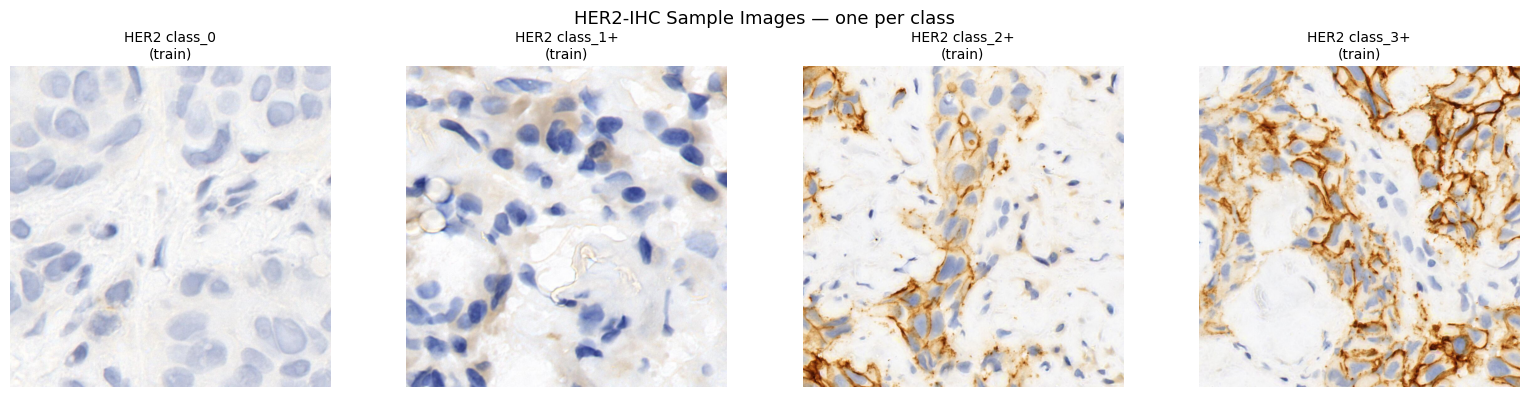

Preview saved to Drive: /content/drive/MyDrive/HER2_Classification/figures/class_preview.png


In [11]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

# Official dataset split names
SPLITS = {
    "train": "train_data_patch",
    "test": "test_data_patch",
}

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
fig.suptitle("HER2-IHC Sample Images — one per class", fontsize=13)

for ax, cls in zip(axes, CLASSES):

    image_path = None

    # Prefer a training image
    for split_name, split_folder in SPLITS.items():

        folder = Path(DATA_DIR) / split_folder / cls

        if not folder.exists():
            continue

        images = sorted([
            p for p in folder.rglob("*")
            if p.suffix.lower() in IMG_EXTS
        ])

        if images:
            image_path = images[0]
            split_used = split_name
            break

    if image_path is None:

        ax.set_title(
            f"HER2 {cls}\n(NO IMAGES FOUND)",
            color="red",
            fontsize=10,
        )
        ax.axis("off")
        continue

    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)

    ax.set_title(
        f"HER2 {cls}\n({split_used})",
        fontsize=10,
    )

    ax.axis("off")

plt.tight_layout()

preview_path = os.path.join(
    FIGURES_DIR,
    "class_preview.png",
)

plt.savefig(preview_path, dpi=150, bbox_inches="tight")
plt.show()

print("Preview saved to Drive:", preview_path)

## 12. Prepare Manifests & Dataset Report

In [12]:
import os
import json
import subprocess
import pandas as pd

cmd = [
    "python",
    "scripts/prepare_data.py",
    "--config", CONFIG,
    "--data-dir", DATA_DIR,
    "--out-dir", MANIFEST_DIR,
]

print("Running:")
print(" ".join(cmd))
print()

import os
import sys

env = os.environ.copy()

# Add the project root to PYTHONPATH
env["PYTHONPATH"] = os.getcwd()

result = subprocess.run(
    cmd,
    text=True,
    capture_output=True,
    env=env,
)

print(result.stdout)

if result.returncode != 0:
    print("========== STDERR ==========")
    print(result.stderr)
    raise RuntimeError("prepare_data.py failed.")

print("✅ Manifests saved to:", MANIFEST_DIR)

report_path = os.path.join(MANIFEST_DIR, "dataset_report.json")

if os.path.exists(report_path):
    with open(report_path) as f:
        dataset_report = json.load(f)

    print("\nDataset Report")
    print(json.dumps(dataset_report, indent=2))

for name in [
    "train_manifest.csv",
    "val_manifest.csv",
    "test_manifest.csv",
]:
    path = os.path.join(MANIFEST_DIR, name)

    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"\n{name}: {len(df)} images")
        display(df.head())

Running:
python scripts/prepare_data.py --config configs/hybrid.yaml --data-dir /content/drive/MyDrive/HER2_Classification/datasets/her2-ihc-40x-patch/Patch-based-dataset --out-dir /content/drive/MyDrive/HER2_Classification/dataset_manifests

{'num_samples': 10997, 'class_counts': {'train': {'class_0': 2728, 'class_1+': 1936, 'class_2+': 814, 'class_3+': 2439}, 'val': {'class_0': 303, 'class_1+': 215, 'class_2+': 91, 'class_3+': 271}, 'test': {'class_0': 758, 'class_1+': 538, 'class_2+': 226, 'class_3+': 678}}}

✅ Manifests saved to: /content/drive/MyDrive/HER2_Classification/dataset_manifests

Dataset Report
{
  "num_samples": 10997,
  "class_counts": {
    "train": {
      "class_0": 2728,
      "class_1+": 1936,
      "class_2+": 814,
      "class_3+": 2439
    },
    "val": {
      "class_0": 303,
      "class_1+": 215,
      "class_2+": 91,
      "class_3+": 271
    },
    "test": {
      "class_0": 758,
      "class_1+": 538,
      "class_2+": 226,
      "class_3+": 678
    }
  }

,image_path,label,split,patient_id,wsi_id
0,/content/drive/MyDrive/HER2_Classification/dat...,class_0,train,NaN,NaN
1,/content/drive/MyDrive/HER2_Classification/dat...,class_1+,train,NaN,NaN
2,/content/drive/MyDrive/HER2_Classification/dat...,class_3+,train,NaN,NaN
3,/content/drive/MyDrive/HER2_Classification/dat...,class_1+,train,NaN,NaN
4,/content/drive/MyDrive/HER2_Classification/dat...,class_3+,train,NaN,NaN



val_manifest.csv: 880 images


,image_path,label,split,patient_id,wsi_id
0,/content/drive/MyDrive/HER2_Classification/dat...,class_0,val,NaN,NaN
1,/content/drive/MyDrive/HER2_Classification/dat...,class_0,val,NaN,NaN
2,/content/drive/MyDrive/HER2_Classification/dat...,class_3+,val,NaN,NaN
3,/content/drive/MyDrive/HER2_Classification/dat...,class_0,val,NaN,NaN
4,/content/drive/MyDrive/HER2_Classification/dat...,class_0,val,NaN,NaN



test_manifest.csv: 2200 images


,image_path,label,split,patient_id,wsi_id
0,/content/drive/MyDrive/HER2_Classification/dat...,class_0,test,NaN,NaN
1,/content/drive/MyDrive/HER2_Classification/dat...,class_0,test,NaN,NaN
2,/content/drive/MyDrive/HER2_Classification/dat...,class_0,test,NaN,NaN
3,/content/drive/MyDrive/HER2_Classification/dat...,class_0,test,NaN,NaN
4,/content/drive/MyDrive/HER2_Classification/dat...,class_0,test,NaN,NaN


In [13]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/content/HER2-model-classification


## 13. Smoke Tests (GATE 2)

Runs one forward pass through the full hybrid model, computes the loss, performs one
optimizer step, updates EMA, saves and reloads a checkpoint, and runs a mini
evaluation. Also triggers pretrained-weight downloads if needed.

Set `RUN_SMOKE_TESTS = False` in § 5 to skip (useful after the first successful run).

In [14]:
import subprocess

cmd = [
    "python",
    "scripts/smoke_test.py",
    "--config", CONFIG,
    "--data-dir", DATA_DIR,
    "--output-dir", SMOKE_DIR,
]

result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)


Traceback (most recent call last):
  File "/content/HER2-model-classification/scripts/smoke_test.py", line 104, in <module>
    main()
  File "/content/HER2-model-classification/scripts/smoke_test.py", line 93, in main
    run_smoke_tests(
TypeError: run_smoke_tests() got an unexpected keyword argument 'output_dir'



## 14. Train

The training script reads `config['training']['resume']` and looks for `latest.pt`
inside `EXPERIMENT_DIR`. If the file exists it resumes; if not it starts from epoch 0.

Checkpoints (`latest.pt` and `best.pt`) are written to Drive after every epoch.

**Output is streamed live** as the subprocess runs: epoch banners, per-batch `tqdm`
progress, training/validation loss, learning rate, validation metrics, elapsed
time/ETA, and checkpoint-saving events all appear in this cell in real time,
exactly as they would in a terminal. `training.log` on Drive is written
independently by the script's own logger and keeps a full persisted copy of
everything shown here.


In [ ]:
import subprocess
import sys
import os

cmd = [
    "python", "-u",
    "scripts/train_hybrid.py",
    "--config", CONFIG,
    "--data-dir", DATA_DIR,
    "--experiment-dir", EXPERIMENT_DIR,
    "--skip-smoke-tests",
]

print("Running:")
print(" ".join(cmd))
print()

# Force the child process's stdout/stderr to be unbuffered at the OS level so
# epoch banners, tqdm batch-progress bars, loss/lr/metric lines, and
# checkpoint-saving messages are flushed as soon as they're written instead of
# sitting in a pipe buffer until the process exits. "-u" covers the
# interpreter itself; PYTHONUNBUFFERED covers any subprocesses it spawns.
env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # merge so ordering matches a real terminal
    bufsize=0,                 # unbuffered: hand us raw bytes as they arrive
    env=env,
)

# Stream raw bytes rather than readline(). tqdm redraws its bar in place using
# "\r" with no trailing "\n" — reading line-by-line would block until a full
# line eventually showed up (e.g. at epoch end), so the bar would appear to
# freeze. Reading raw chunks and writing them straight to sys.stdout lets the
# notebook's output area interpret "\r"/"\n" exactly like a terminal would,
# so the progress bar updates live, batch by batch.
try:
    while True:
        chunk = process.stdout.read(1024)
        if chunk:
            sys.stdout.write(chunk.decode("utf-8", errors="replace"))
            sys.stdout.flush()
        elif process.poll() is not None:
            break
except KeyboardInterrupt:
    process.terminate()
    raise
finally:
    process.stdout.close()

returncode = process.wait()

if returncode != 0:
    raise RuntimeError(f"train_hybrid.py failed (exit code {returncode}).")

print("\n✅ Training finished.")

# training.log on Drive was written throughout the run by the script's own
# logger (see src/logging_utils.setup_logger), independently of the live
# stream above — it's already complete and persisted at this point.
for name, path in [("best.pt", BEST_CKPT), ("latest.pt", LATEST_CKPT)]:
    if os.path.exists(path):
        print(f"{name}: {os.path.getsize(path)/1e6:.1f} MB")
    else:
        print(f"{name}: MISSING")


## 15. Training Log Tail & Checkpoint Inventory

Shows the latest training log lines and saved artifacts immediately after training.

In [ ]:
if os.path.exists(TRAINING_LOG):
    print(f"Last {LOG_TAIL_LINES} lines from:", TRAINING_LOG)
    with open(TRAINING_LOG, "r", encoding="utf-8") as f:
        lines = f.readlines()
    print("".join(lines[-LOG_TAIL_LINES:]))
else:
    print("No training log found yet:", TRAINING_LOG)

artifact_rows = []
for path in sorted(Path(EXPERIMENT_DIR).glob("*")):
    if path.is_file():
        artifact_rows.append({
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1e6, 3),
        })
if artifact_rows:
    display(pd.DataFrame(artifact_rows))
else:
    print("No top-level experiment artifacts found.")

## 16. Training Curves

Reads `history.csv` produced by the training loop and plots loss, accuracy, and
learning-rate schedule.

In [ ]:
_history_path = f'{EXPERIMENT_DIR}/history.csv'
assert os.path.exists(_history_path), (
    f'history.csv not found: {_history_path}\n'
    f'Did training complete at least one epoch?'
)

history = pd.read_csv(_history_path)
print('Epochs recorded:', len(history))
display(history.tail(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HER2 Hybrid Ensemble — Training Curves', fontsize=14)

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[0].plot(history['epoch'], history['train_loss'],
             label='Train Loss', color='steelblue', alpha=0.85)
axes[0].plot(history['epoch'], history['val_loss'],
             label='Val Loss',   color='tomato',    alpha=0.85)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1].plot(history['epoch'], history['val_accuracy'],
             label='Val Accuracy',          color='seagreen',   alpha=0.85)
axes[1].plot(history['epoch'], history['val_balanced_accuracy'],
             label='Val Balanced Accuracy', color='darkorange', alpha=0.85)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Learning Rate ─────────────────────────────────────────────────────────────
if 'lr' in history.columns:
    axes[2].plot(history['epoch'], history['lr'], color='mediumpurple', alpha=0.85)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'LR not logged', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
_curves_path = os.path.join(FIGURES_DIR, 'training_curves.png')
plt.savefig(_curves_path, dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to Drive:', _curves_path)

# ── Best-epoch summary ─────────────────────────────────────────────────────────
_best = history.loc[history['val_loss'].idxmin()]
print('\nBest epoch summary:')
print(f"  Epoch            : {int(_best['epoch'])}")
print(f"  Val loss         : {_best['val_loss']:.6f}")
print(f"  Val accuracy     : {_best['val_accuracy']:.4f}")
print(f"  Val balanced acc : {_best['val_balanced_accuracy']:.4f}")

## 17. Evaluate Best Checkpoint

Runs evaluation against the test set using `best.pt`. The training script already
saves test metrics in `EXPERIMENT_DIR`; this cell writes a clean final-eval folder
for reporting.

In [ ]:
assert os.path.exists(BEST_CKPT), (
    f"Best checkpoint not found: {BEST_CKPT}\n"
    "Did training complete at least one epoch and save an improvement?"
)

run_command([
    "python", "scripts/evaluate_hybrid.py",
    "--config", f"{EXPERIMENT_DIR}/config.yaml",
    "--checkpoint", BEST_CKPT,
    "--data-dir", DATA_DIR,
    "--output-dir", EVAL_DIR,
])

print("Evaluation complete. Results in:", EVAL_DIR)

## 18. View Metrics & Figures

Displays key test-set metrics, per-class metrics, and saved evaluation plots.

In [ ]:
_metrics_path = f'{EVAL_DIR}/metrics.json'
assert os.path.exists(_metrics_path), (
    f'metrics.json not found: {_metrics_path}\n'
    f'Run the evaluation cell (§ 17) first.'
)

with open(_metrics_path) as f:
    metrics = json.load(f)

# ── Key scalar metrics ────────────────────────────────────────────────────────
print('=== Test-set Metrics (best.pt) ===')
_key_metrics = [
    ('Accuracy',            metrics.get('accuracy')),
    ('Balanced Accuracy',   metrics.get('balanced_accuracy')),
    ('Weighted F1',         metrics.get('weighted_f1')),
    ('ROC-AUC (OvR macro)', metrics.get('roc_auc_ovr_macro')),
    ('Weighted Precision',  metrics.get('weighted_precision')),
    ('Weighted Recall',     metrics.get('weighted_recall')),
    ('Specificity (macro)', (metrics.get('specificity') or {}).get('macro')),
]
for _name, _val in _key_metrics:
    _val_str = f'{_val:.4f}' if _val is not None else 'N/A'
    print(f'  {_name:<28}: {_val_str}')

# ── Per-class breakdown ────────────────────────────────────────────────────────
if 'per_class' in metrics:
    print('\n=== Per-Class Metrics ===')
    _hdr2 = f"  {'Class':<8} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}"
    print(_hdr2)
    print('  ' + '-' * (len(_hdr2) - 2))
    for _cls, _v in metrics['per_class'].items():
        print(f"  {_cls:<8} {_v['precision']:>10.4f} {_v['recall']:>10.4f}"
              f" {_v['f1']:>10.4f} {_v['support']:>10}")

# ── Figures ────────────────────────────────────────────────────────────────────
print('\n=== Figures ===')
for _name in ['confusion_matrix.png', 'roc.png', 'pr.png']:
    _path = f'{EVAL_DIR}/{_name}'
    if os.path.exists(_path):
        print(_path)
        display(IpyImage(filename=_path))
    else:
        print(f'  [missing] {_name}')

## 19. Error Analysis: Misclassified Test Examples

Displays a small set of mistakes with the model confidence for the predicted class.
This is the fastest visual check for label issues, staining/domain shifts, or
classes the model confuses.

In [ ]:
pred_path = f"{EVAL_DIR}/predictions.csv"
assert os.path.exists(pred_path), f"predictions.csv not found: {pred_path}"

pred_df = pd.read_csv(pred_path)
mistakes = pred_df[pred_df["true_label"] != pred_df["predicted_label"]].copy()
print(f"Misclassified images: {len(mistakes)} / {len(pred_df)}")

if not mistakes.empty:
    def predicted_confidence(row):
        col = f"probability_{row['predicted_label']}"
        return row[col] if col in row else np.nan

    mistakes["predicted_confidence"] = mistakes.apply(predicted_confidence, axis=1)
    display_cols = ["image_path", "true_label", "predicted_label", "predicted_confidence"]
    display(mistakes[display_cols].sort_values("predicted_confidence", ascending=False).head(20))

    sample_mistakes = mistakes.sort_values("predicted_confidence", ascending=False).head(8)
    cols = 4
    rows = int(np.ceil(len(sample_mistakes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample_mistakes.iterrows()):
        image_path = row["image_path"]
        if os.path.exists(image_path):
            ax.imshow(Image.open(image_path).convert("RGB"))
        ax.set_title(
            f"true {row['true_label']} / pred {row['predicted_label']}\n"
            f"conf {row['predicted_confidence']:.3f}",
            fontsize=10,
        )
        ax.axis("off")
    for ax in axes[len(sample_mistakes):]:
        ax.axis("off")
    plt.tight_layout()
    error_grid_path = os.path.join(FIGURES_DIR, "misclassified_examples.png")
    plt.savefig(error_grid_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Error grid saved to Drive:", error_grid_path)
else:
    print("No misclassifications in predictions.csv.")

## 20. Save Full Results JSON to Drive

Writes `EXPERIMENT_DIR/results_summary.json`, capturing the config, best epoch,
test metrics, dataset report, and artifact paths.

In [ ]:
_exp_config_path = f"{EXPERIMENT_DIR}/config.yaml"
assert os.path.exists(_exp_config_path), (
    f"Experiment config.yaml not found: {_exp_config_path}\n"
    "Training must have run at least once to save config.yaml."
)

with open(_exp_config_path) as f:
    exp_config = yaml.safe_load(f)

history_df = pd.read_csv(f"{EXPERIMENT_DIR}/history.csv")
best_row = history_df.loc[history_df["val_loss"].idxmin()].to_dict()
dataset_report = read_json(f"{MANIFEST_DIR}/dataset_report.json") if os.path.exists(f"{MANIFEST_DIR}/dataset_report.json") else {}

results_summary = {
    "training": {
        "epochs_run": int(len(history_df)),
        "best_epoch": {k: (float(v) if isinstance(v, float) else v) for k, v in best_row.items()},
        "config": {
            "epochs": exp_config["training"]["epochs"],
            "batch_size": exp_config["training"]["batch_size"],
            "learning_rate": exp_config["training"]["learning_rate"],
            "weight_decay": exp_config["training"]["weight_decay"],
            "warmup_epochs": exp_config["training"]["warmup_epochs"],
            "label_smoothing": exp_config["training"]["label_smoothing"],
            "mixup_alpha": exp_config["training"]["mixup_alpha"],
            "ema_decay": exp_config["training"]["ema_decay"],
        },
    },
    "model": {
        "eva_name": exp_config["model"]["eva_name"],
        "vit_name": exp_config["model"]["vit_name"],
        "convnext_name": exp_config["model"]["convnext_name"],
        "fusion_dim": exp_config["model"]["fusion_dim"],
    },
    "dataset_report": dataset_report,
    "test_metrics": metrics,
    "paths": {
        "data_dir": DATA_DIR,
        "experiment_dir": EXPERIMENT_DIR,
        "best_checkpoint": BEST_CKPT,
        "final_eval_dir": EVAL_DIR,
    },
}

_summary_path = f"{EXPERIMENT_DIR}/results_summary.json"
with open(_summary_path, "w") as f:
    json.dump(results_summary, f, indent=2, default=str)

print("Results summary saved to Drive:", _summary_path)
print("Checkpoints on Drive:", EXPERIMENT_DIR)
print("Figures on Drive    :", FIGURES_DIR)

## 21. Download Best Checkpoint (Optional)

Set `DOWNLOAD_BEST = True` in section 5 to trigger a browser download of `best.pt`.

In [ ]:
if DOWNLOAD_BEST:
    from google.colab import files
    if os.path.exists(BEST_CKPT):
        print('Downloading:', BEST_CKPT)
        files.download(BEST_CKPT)
    else:
        print('best.pt not found — cannot download:', BEST_CKPT)
else:
    print('Download skipped (DOWNLOAD_BEST = False).')
    print('Best checkpoint remains on Drive:', BEST_CKPT)

---
## Drive Folder Structure & Reading the Result

```
MyDrive/HER2_Classification/
  datasets/HER2-IHC-40x/              <- source data (train/ val/ test/)
  dataset_manifests/                  <- CSV manifests and dataset_report.json
  experiments/
    exp001_hybrid_end_to_end/
      best.pt                         <- best checkpoint (lowest val loss)
      latest.pt                       <- most recent checkpoint (auto-resume)
      history.csv                     <- per-epoch training log
      config.yaml                     <- snapshot of the config used
      environment.json                <- Python / GPU environment info
      training.log                    <- training log
      metrics.json                    <- test metrics from training script
      results_summary.json            <- full results JSON
      final_eval/
        metrics.json
        predictions.csv
        classification_report.json
        confusion_matrix.png
        roc.png
        pr.png
    smoke_test/                       <- smoke-test outputs
  figures/
    class_preview.png
    training_curves.png
    misclassified_examples.png
```

Disconnect recovery: reconnect the Colab runtime and run all cells. The notebook
detects `latest.pt` and resumes from the last saved epoch. If no checkpoint is
present, it starts from epoch 0.

Result checklist:
- Prefer balanced accuracy and per-class F1 over raw accuracy when classes are imbalanced.
- Inspect the confusion matrix for clinically important confusions, especially `1+` vs `2+`.
- Review high-confidence mistakes before trusting aggregate metrics; they often reveal label
  problems, stain/domain shift, or split leakage issues.
- Treat ROC/PR curves as support for the scalar metrics, not as replacements for per-class review.